# ECG-based apnea detection — complete research project

This notebook takes you from the dataset to **trained models, held-out evaluation and predictions**. Outputs are saved so you can read the results immediately. Each code cell is commented. Supporting implementation lives in `src/` for reproducibility.

**Medical context:** ECG measures heart electrical activity. Apnea means interrupted breathing; hypopnea means reduced breathing. We study ECG patterns associated with the supplied minute-spaced breathing labels. An A annotation means apnea is in progress at the minute's beginning according to the archive's corrected documentation. This is not a clinical diagnosis, precise event counter, or advance warning system.

**Study design:** remove c06's known overlap with c05; hold out entire conservative recording groups; compare three models using development-only cross-validation; select threshold on development predictions; evaluate once on the holdout; then refit the selected model on all 34 eligible labeled records for future research use. Group identities are inferred candidates, not verified patient IDs.


**Observed result:** selected random forest achieved only **52.6% balanced accuracy and 33.0% sensitivity on held-out groups** (development balanced accuracy was 80.6%). This is a complete research baseline, but its generalization is inadequate for screening claims. See MODEL_CARD.md for interpretation.


In [1]:
# Locate the project whether this notebook is opened from the project or outputs folder.
from pathlib import Path
import sys, json
ROOT = next((p for p in [Path.cwd(), Path.cwd().parent] if (p/'src'/'train.py').exists()), None)
if ROOT is None:
    ROOT = Path(r"D:\Mtech Research\apnea_project")
assert (ROOT/'src'/'train.py').exists(), 'Set ROOT to the project directory.'
sys.path.insert(0, str(ROOT/'src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from ecg import Archive, FEATURES, WINDOW, extract_window
OUT = ROOT/'outputs'
config = json.loads((ROOT/'config.json').read_text())
print('Project:', ROOT)
print('Raw data:', config['dataset_zip'])


Project: D:\Mtech Research\apnea_project
Raw data: D:/Mtech Research/apnea-ecg-database-1.0.0.zip


## 1. Reproduce the pipeline when needed
The supplied models are already trained. Leave the switch off to inspect the completed results. Turn it on to repeat extraction/training; verified cached features are reused. It takes several minutes and replaces named result artifacts. Training settings are fixed in `config.json`; do not tune them against the held-out results.

In [2]:
# Optional retraining. No training is needed just to read this notebook.
RUN_TRAINING = False
if RUN_TRAINING:
    from train import run
    from threadpoolctl import threadpool_limits
    with threadpool_limits(limits=4):
        run(config)
else:
    print('Using the completed training artifacts.')


Using the completed training artifacts.


## 2. Understand the feature table
Each row below corresponds to 60 seconds of ECG: 6,000 measurements at 100 Hz. `label=1` is A and `label=0` is N. `record`, `group`, `minute` and `label` are metadata, not model inputs. `quality_ok` summarizes predefined screening rules, while the primary model evaluation includes all complete windows.

Features include ECG variation, power summaries, candidate heartbeat counts, RR intervals (spacing between beats), RMSSD (successive interval variation), and heartbeat amplitude summaries. They are exploratory numerical features, not clinical measurements. Short-window spectral estimates and automated peaks require particular caution.

In [3]:
# Load only trusted, project-generated pickle files: pickle is not a safe interchange format.
features = pd.read_pickle(OUT/'features.pkl')
display(features[['record','minute','group','label','quality_ok','rr_mean','rr_std','rmssd','peak_count']].head(20))
display(features.groupby('record').agg(windows=('label','size'),apnea_fraction=('label','mean'),
                                     quality_coverage=('quality_ok','mean')))
print('Numeric model inputs:', FEATURES)
print('Total windows:', len(features), '| Records:', features.record.nunique())


,record,minute,group,label,quality_ok,rr_mean,rr_std,rmssd,peak_count
0,a01,0,a01,0,True,0.900000,0.059442,0.042859,67
1,a01,1,a01,0,True,0.838714,0.045448,0.037513,71
2,a01,2,a01,0,True,0.811644,0.079829,0.042098,74
3,a01,3,a01,0,True,0.748228,0.060708,0.027988,80
4,a01,4,a01,0,True,0.794595,0.045979,0.028405,75
5,a01,5,a01,0,True,0.830000,0.057163,0.035173,72
6,a01,6,a01,0,True,0.804932,0.084693,0.080855,74
7,a01,7,a01,0,True,0.712805,0.068365,0.061794,83
8,a01,8,a01,0,True,0.716585,0.066557,0.021023,83
9,a01,9,a01,0,True,0.819306,0.063581,0.038088,73


,windows,apnea_fraction,quality_coverage
record,,,
a01,489,0.961145,1.000000
a02,528,0.795455,1.000000
a03,519,0.473988,1.000000
a04,492,0.920732,1.000000
a05,453,0.609272,0.995585
a06,509,0.404715,1.000000
a07,510,0.629412,1.000000
a08,500,0.378000,1.000000
a09,495,0.769697,1.000000


Numeric model inputs: ['ecg_std', 'ecg_iqr', 'ecg_range', 'diff_std', 'flat_fraction', 'rail_fraction', 'power_low', 'power_mid', 'power_high', 'peak_count', 'bad_rr_fraction', 'rr_mean', 'rr_std', 'rr_median', 'rr_iqr', 'rmssd', 'pnn50', 'rr_trend', 'rr_power_slow', 'rr_power_fast', 'amp_mean', 'amp_std', 'amp_iqr', 'amp_rmssd', 'amp_resp_power']
Total windows: 16556 | Records: 34


## 3. Inspect an actual minute and heartbeat detections
The detector filters each completed minute independently, finds energy peaks and refines their positions. It never reads subsequent minutes. Red markers are algorithm outputs, not expert-certified heartbeat locations. The model is available only after a full minute has been collected.

,sample,time_seconds,ECG_mV
0,0,0.00,-0.060
1,1,0.01,-0.065
2,2,0.02,-0.060
3,3,0.03,-0.075
4,4,0.04,-0.065
5,5,0.05,-0.070
6,6,0.06,-0.070
7,7,0.07,-0.090
8,8,0.08,-0.080
9,9,0.09,-0.095


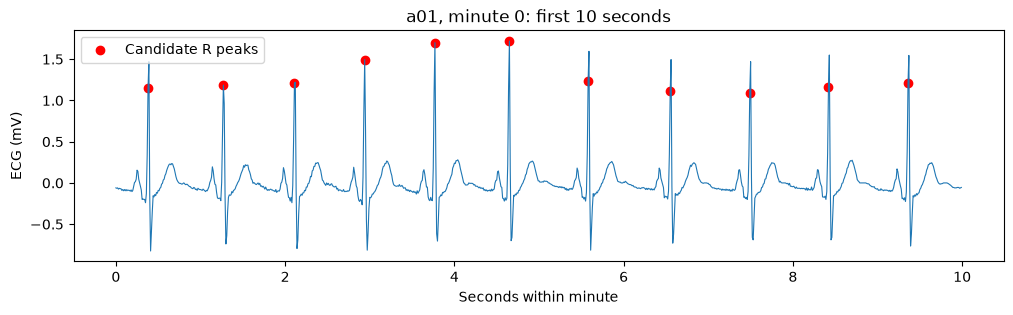

Annotation: N
Quality flags: None under these rules


In [4]:
# Change RECORD and MINUTE to explore a different complete window.
RECORD, MINUTE = 'a01', 0
archive = Archive(config['dataset_zip'])
signal = archive.signal(RECORD)
annotations = dict(archive.annotations(RECORD))
start = MINUTE * WINDOW
window = signal[start:start+WINDOW]
feat, quality_reason, peaks = extract_window(window)
display(pd.DataFrame({'sample':np.arange(20)+start,
                      'time_seconds':(np.arange(20)+start)/100,'ECG_mV':window[:20]}))
fig, ax = plt.subplots(figsize=(12,3))
ax.plot(np.arange(1000)/100,window[:1000],lw=0.8)
visible = peaks[peaks<1000]
ax.scatter(visible/100,window[visible],c='red',label='Candidate R peaks')
ax.set(xlabel='Seconds within minute',ylabel='ECG (mV)',title=f'{RECORD}, minute {MINUTE}: first 10 seconds')
ax.legend(); plt.show()
print('Annotation:', {1:'N',8:'A'}.get(annotations.get(start),'Unavailable'))
print('Quality flags:', quality_reason or 'None under these rules')
archive.close()


## 4. Verify the evaluation boundary
Randomly dividing minutes can leak patient/record characteristics across sets. Here whole candidate groups stay together. Equal age/sex/height/weight links are formed across the full archive; the known duplicate pair is linked explicitly. c06 is excluded. This conservative heuristic does not prove independent people.

The original x-recordings have no minute-level labels in this archive, so the evaluated holdout is taken from the 34 eligible labeled records. The x-recordings can receive predictions but cannot yield supervised metrics here.

In [5]:
# Audit the saved split without altering it based on model performance.
split = json.loads((OUT/'split_manifest.json').read_text())
assert not set(split['development_groups']) & set(split['holdout_groups'])
display(pd.DataFrame({'partition':['Development','Holdout'],
                      'records':[', '.join(split['development_records']),', '.join(split['holdout_records'])],
                      'groups':[len(split['development_groups']),len(split['holdout_groups'])]}))
metrics = json.loads((OUT/'metrics.json').read_text())
print('Held-out complete windows:', metrics['holdout_windows'])


,partition,records,groups
0,Development,"a02, a03, a04, a05, a06, a07, a08, a10, a12, a...",18
1,Holdout,"a01, a09, a11, a14, a17, a18, b05, c02, c09",6


Held-out complete windows: 4332


## 5. Compare trained models on development data
Logistic regression is a linear baseline. Random forest combines decision trees. Histogram gradient boosting adds trees sequentially to correct errors. Median imputation and scaling, where applicable, are fitted inside each training fold.

Selection uses development out-of-fold average precision. The operating threshold maximizes development out-of-fold balanced accuracy on a fixed grid. These development scores are selection estimates, not independent final results. No holdout score chooses the winner.

In [6]:
# Display the genuine development comparison saved during training.
comparison = pd.DataFrame(metrics['development_comparison'])
display(comparison[['model','average_precision','auroc','balanced_accuracy','sensitivity','specificity','threshold']])
print('Chosen model:', metrics['selected_model'])
print('Chosen threshold:', metrics['threshold'])


,model,average_precision,auroc,balanced_accuracy,sensitivity,specificity,threshold
0,logistic_regression,0.754010,0.866818,0.792788,0.810596,0.774981,0.39
1,random_forest,0.759040,0.874968,0.805678,0.866530,0.744825,0.33
2,hist_gradient_boosting,0.715876,0.844152,0.771206,0.896999,0.645413,0.08


Chosen model: random_forest
Chosen threshold: 0.32999999999999996


## 6. Held-out results and uncertainty
Sensitivity asks how many A labels were detected; specificity asks how many N labels were rejected; precision asks how many positive predictions were correct. Average precision summarizes the precision-recall tradeoff; its reference level depends on prevalence. Scores are uncalibrated model outputs, not disease probabilities.

Confidence intervals resample entire held-out candidate groups rather than treating correlated minutes as independent. The small number of groups makes uncertainty substantial. The final all-data refit has no separate independent evaluation: these results belong to `evaluation_model.joblib`.

,n,positive,prevalence,threshold,accuracy,balanced_accuracy,sensitivity,specificity,precision,f1,auroc,average_precision,brier,tn,fp,fn,tp
Selected evaluation model,4332,2112,0.487535,0.33,0.531163,0.526271,0.330019,0.722523,0.530845,0.407007,0.623293,0.540899,0.302377,1604,616,1415,697
Always N,4332,2112,0.487535,0.50,0.512465,0.500000,0.000000,1.000000,0.000000,0.000000,0.500000,0.487535,0.487535,2220,0,2112,0


,low,high,valid_replicates
balanced_accuracy,0.409558,0.662273,500.0
sensitivity,0.160200,0.609160,500.0
specificity,0.497243,0.845230,500.0
f1,0.194545,0.561533,500.0
auroc,0.441706,0.760162,500.0
average_precision,0.246212,0.822497,500.0


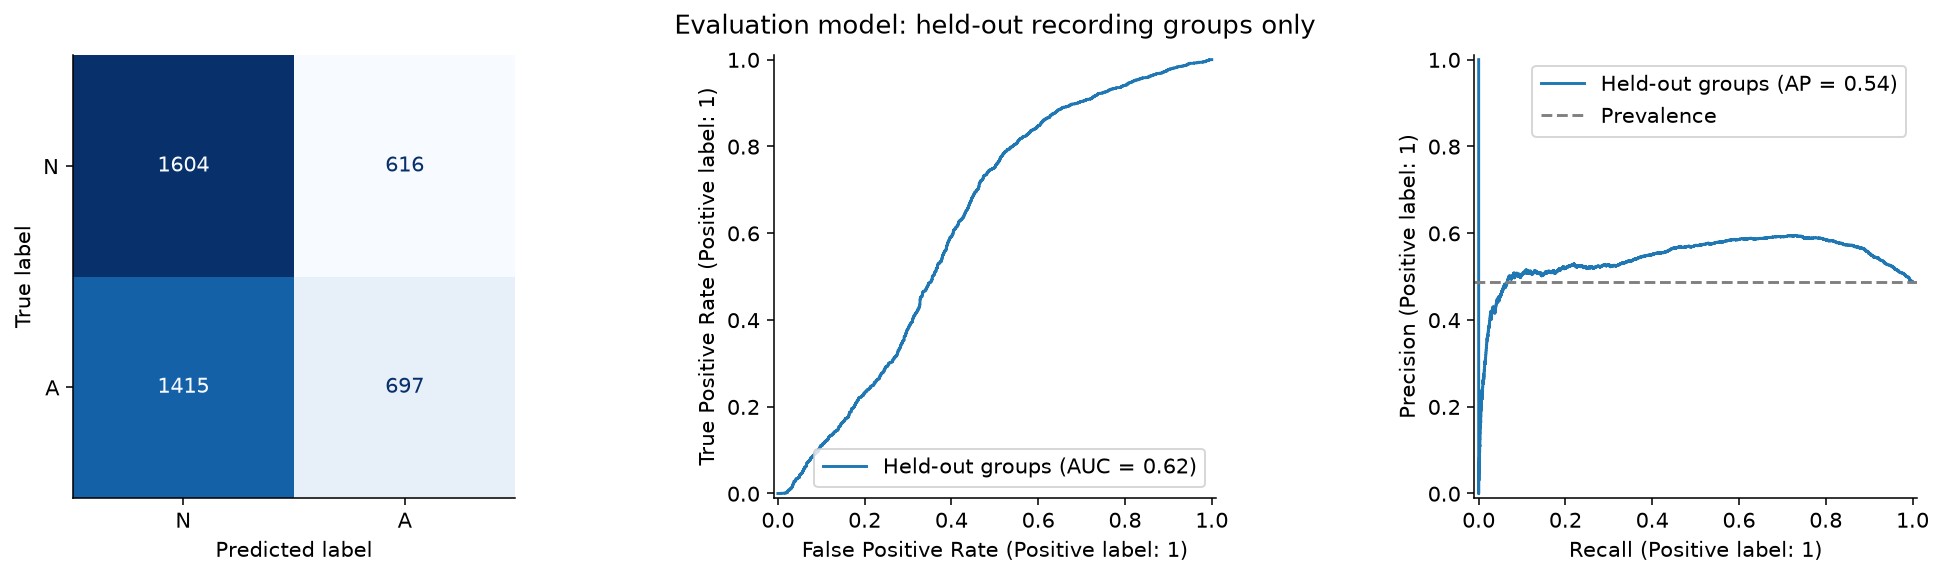

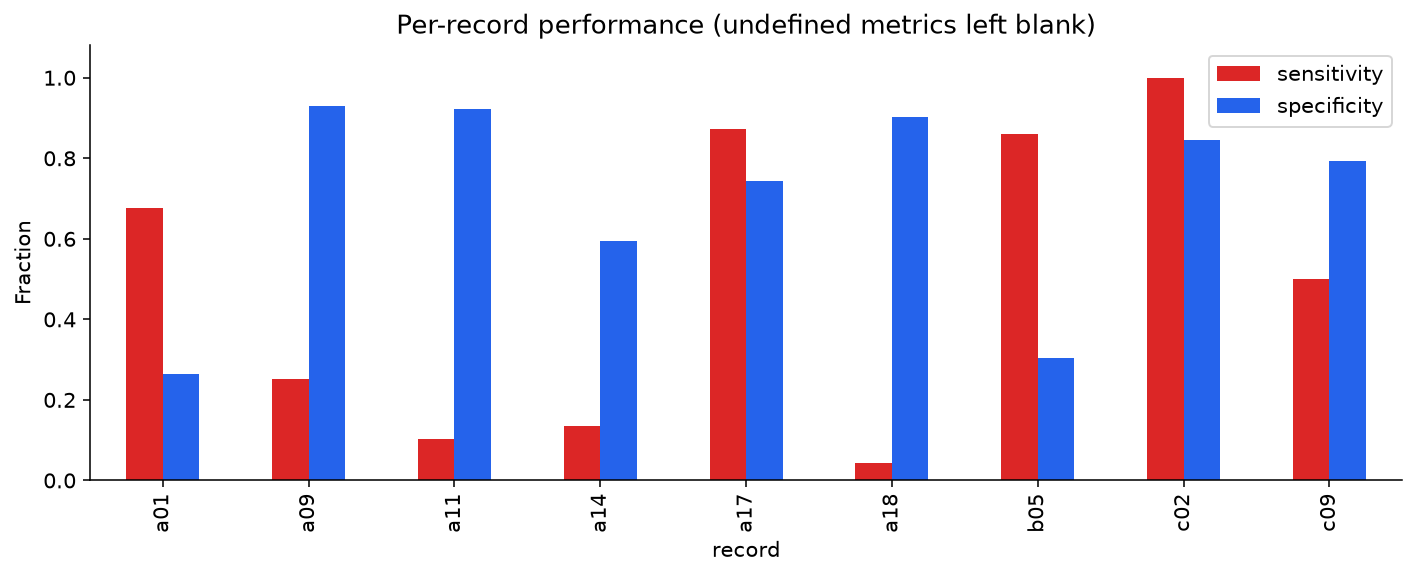

In [7]:
# Compare against a model that always predicts N, and show group-bootstrap intervals.
display(pd.DataFrame([metrics['holdout'],metrics['always_normal_baseline']],
                     index=['Selected evaluation model','Always N']))
display(pd.DataFrame(metrics['holdout_group_bootstrap_95pct']).T)
display(Image(filename=str(OUT/'figures/holdout_evaluation.png')))
display(Image(filename=str(OUT/'figures/per_record.png')))


## 7. Signal quality and noise robustness
Predefined flags cover very low variation, clipping, unreasonable peak counts and too many implausible RR intervals. The primary result includes all windows. The accepted-only result is secondary and must be read alongside coverage: rejecting difficult windows can improve apparent accuracy while reducing usefulness.

Synthetic white noise at 20 and 10 dB SNR is applied to the same predetermined subset of held-out windows. Lower SNR means stronger noise. These stressors do not simulate all real sensor artifacts, and these results must not be used to retune the held-out experiment.

Quality coverage on holdout: 98.0%


,n,positive,prevalence,threshold,accuracy,balanced_accuracy,sensitivity,specificity,precision,f1,auroc,average_precision,brier,tn,fp,fn,tp
0,4245,2107,0.496349,0.33,0.531684,0.530221,0.329853,0.730589,0.546814,0.411486,0.628974,0.553106,0.305929,1562,576,1412,695


,condition,n,coverage,average_precision,balanced_accuracy,sensitivity,specificity
0,clean sampled windows,135,0.970370,0.519185,0.525519,0.338710,0.712329
1,white noise 20 dB SNR,135,0.970370,0.530923,0.514251,0.370968,0.657534
2,white noise 10 dB SNR,135,0.985185,0.557702,0.598542,0.580645,0.616438


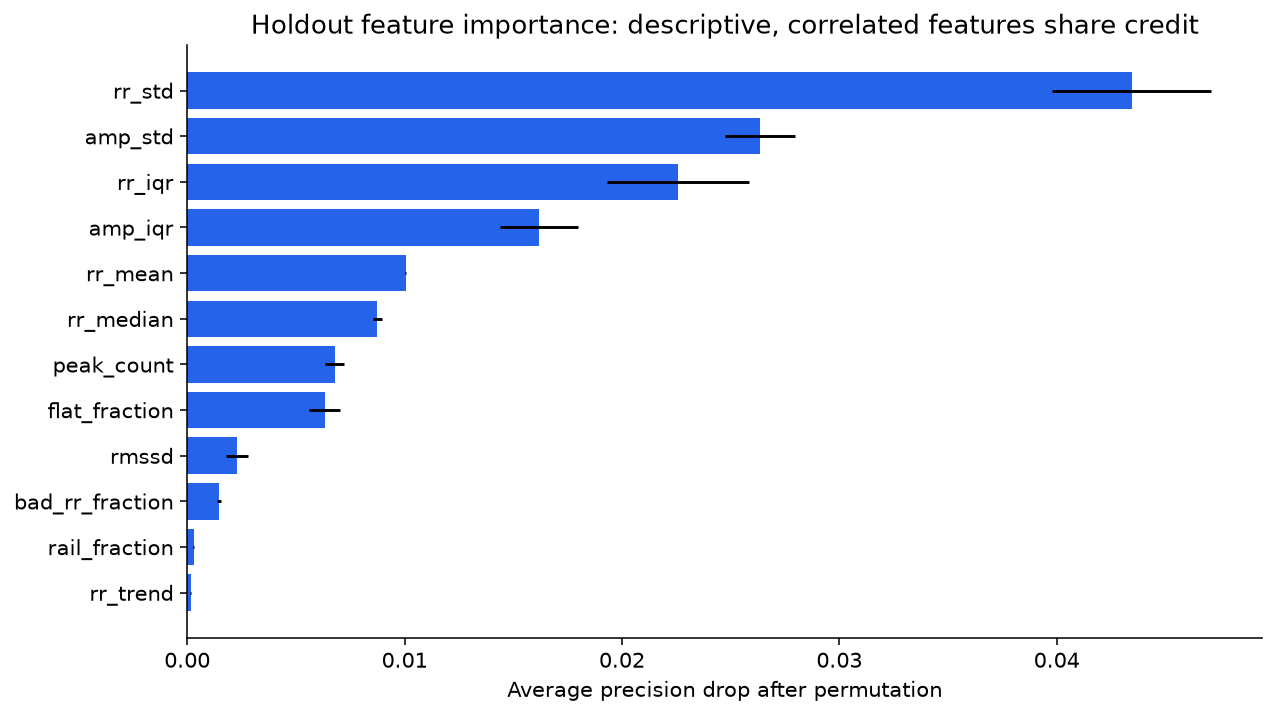

In [8]:
# Inspect both retained-data performance and the fraction of data retained.
print(f"Quality coverage on holdout: {metrics['quality_coverage']:.1%}")
display(pd.DataFrame([metrics['quality_accepted_holdout']]))
display(pd.DataFrame(metrics['robustness'])[['condition','n','coverage','average_precision',
                                          'balanced_accuracy','sensitivity','specificity']])
display(Image(filename=str(OUT/'figures/feature_importance.png')))


## 8. Make predictions using the saved final model
The final artifact is refitted on all 34 eligible labeled records. It is useful for subsequent experiments, but predictions on those training records are not new validation. The example below predicts x01, whose minute labels are unavailable in this archive. New external recordings must be single-channel ECG at 100 Hz in millivolts.

Only load model files you trust: joblib uses pickle. A quality warning means inspect the input rather than treating the binary output as reliable.

,record,minute,start_sample,label,quality_ok,quality_reason,score,prediction,status
0,x01,0,0,NaN,False,low_variation,0.529109,1,review_signal_quality
1,x01,1,6000,NaN,False,low_variation,0.495044,1,review_signal_quality
2,x01,2,12000,NaN,False,low_variation,0.499965,1,review_signal_quality
3,x01,3,18000,NaN,False,low_variation,0.480899,1,review_signal_quality
4,x01,4,24000,NaN,False,low_variation;rr_quality,0.493959,1,review_signal_quality
5,x01,5,30000,NaN,False,low_variation,0.483936,1,review_signal_quality
6,x01,6,36000,NaN,False,low_variation,0.481613,1,review_signal_quality
7,x01,7,42000,NaN,False,low_variation,0.522570,1,review_signal_quality
8,x01,8,48000,NaN,False,low_variation,0.488812,1,review_signal_quality
9,x01,9,54000,NaN,False,low_variation,0.480136,1,review_signal_quality


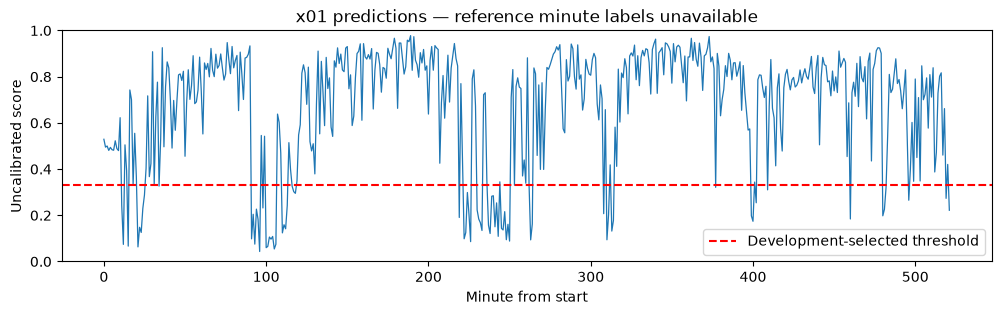

CLI: .venv\Scripts\python.exe src/predict.py --record x02 --output outputs/x02_predictions.json


In [9]:
# Load the project-generated model and use exactly the same feature extractor as training.
import joblib
from predict import predict_frame
MODEL = joblib.load(OUT/'final_model.joblib')
demo_path = OUT/'x01_predictions.json'
# The command-line demo has already generated these predictions using the final model.
predictions = pd.read_json(demo_path)
display(predictions.head(20))
fig, ax = plt.subplots(figsize=(12,3))
ax.plot(predictions.minute,predictions.score,lw=0.9)
ax.axhline(MODEL['threshold'],c='red',ls='--',label='Development-selected threshold')
ax.set(xlabel='Minute from start',ylabel='Uncalibrated score',title='x01 predictions — reference minute labels unavailable',ylim=(0,1))
ax.legend(); plt.show()
print('CLI: .venv\\Scripts\\python.exe src/predict.py --record x02 --output outputs/x02_predictions.json')


## 9. Run verification checks
Tests compare the custom annotation reader to WFDB, confirm the duplicate, verify group disjointness, check signal validation and synthetic heartbeat timing, and reproduce saved predictions from the evaluation artifact. They test software consistency; they do not clinically validate the detector.

In [10]:
# Display the already executed test log; rerun via the command below after changing code.
test_log = OUT/'verification.txt'
print(test_log.read_text() if test_log.exists() else 'Run tests/test_pipeline.py to generate verification results.')
print('Rerun: .venv\\Scripts\\python.exe tests/test_pipeline.py')


test_decoder_against_independent_wfdb (__main__.PipelineTests.test_decoder_against_independent_wfdb) ... ok
test_extraction_inference_parity (__main__.PipelineTests.test_extraction_inference_parity) ... ok
test_flat_window_and_input_validation (__main__.PipelineTests.test_flat_window_and_input_validation) ... ok
test_known_duplicate_and_grouping (__main__.PipelineTests.test_known_duplicate_and_grouping) ... ok
test_splits_and_saved_prediction_parity (__main__.PipelineTests.test_splits_and_saved_prediction_parity) ... ok
test_synthetic_heartbeat_spacing (__main__.PipelineTests.test_synthetic_heartbeat_spacing) ... ok

----------------------------------------------------------------------
Ran 6 tests in 0.966s

OK

Rerun: .venv\Scripts\python.exe tests/test_pipeline.py


## 10. Deliverables and research scope

- `results_report.html`: standalone report with tables and charts.
- `evaluation_model.joblib`: development-only model used for held-out results.
- `final_model.joblib`: all-eligible-data refit for future research inference.
- `features.pkl`: complete feature table; `split_manifest.json`: frozen grouping and partition.
- `holdout_predictions.pkl`, `per_record_metrics.json`, `metrics.json`: detailed evaluation artifacts.
- `src/predict.py`: command-line inference for ZIP record IDs or supported external WFDB records.
- `viewer.ps1`: start the localhost prediction viewer, then open `http://127.0.0.1:8765`.

The delivered contribution is a reproducible baseline with conservative grouping, quality analysis and a controlled noise experiment. It is not a claim of a novel algorithm. To develop a publishable contribution, review related work, add independently collected data, validate heartbeat detections with a clinician, and pre-register a specific improvement before comparing it on a new evaluation set.

References: [PhysioNet Apnea-ECG](https://physionet.org/content/apnea-ecg/1.0.0/), [WFDB annotation format](https://physionet.org/physiotools/wag/annot-5.htm), [scikit-learn grouped validation](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators-for-grouped-data).
